# ESS Telemetry Exploration

Explores Environmental Sensor Suite (ESS) data from the Rubin Observatory EFD.
Each physical sensor is identified by its `salIndex`.  Pass `index=salIndex`
to any `EfdClient` query to isolate a specific sensor.

Sensor config reference: https://github.com/lsst-ts/ts_config_ocs/blob/develop/ESS/v8/_init.yaml

## Sensor Index

| salIndex | Subsystem | Location / Description | Measures |
|---|---|---|---|
| 104 | TMA | TMA accelerometers (SST top end ring ±x/y, spider spindle, M2 surrogate) | 3-axis acceleration @ 100 Hz |
| 105 | MTDome | Spectrum analyzer 1 — dome wall | RF spectrum |
| 106 | M2 | M2 mirror — tangent links A1–A6 | Temperature |
| 109 | MTDome | Spectrum analyzer 2 — dome wall | RF spectrum to 30 MHz |
| 110 | TMA | TMA deployable platform (Gill anemometer) | Air turbulence |
| 111 | Camera | Camera inlet plane | Humidity / temperature |
| 112 | M2 | M2 assembly | Humidity / temperature |
| 113 | M1M3 | M1M3 cell | Humidity / temperature |
| 114 | M1M3 | Thermal scanner 1 | Thermal profile |
| 115 | M1M3 | Thermal scanner 2 | Thermal profile |
| 116 | M1M3 | Thermal scanner 3 | Thermal profile |
| 117 | M1M3 | Thermal scanner 4 | Thermal profile |
| 121 | Camera | Hexapod struts 7–12, rotator motors 1–2 | Temperature |
| 122 | M2 | M2 hexapod struts 1–6, truss structure | Temperature |
| 123 | TMA | Top ring −X/−Y (3D anemometer) | Air turbulence |
| 124 | TMA | Top ring +X/−Y (3D anemometer) | Air turbulence |
| 125 | TMA | Top ring +X/+Y (3D anemometer) | Air turbulence |
| 126 | TMA | Top ring −X/+Y (3D anemometer) | Air turbulence |
| 127 | MTDome | Dome particulate 1 (Sensirion SPS30) | Particulate matter |
| 128 | MTDome | Dome particulate 2 | Particulate matter |
| 129 | MTDome | Dome particulate 3 | Particulate matter |
| 201 | AuxTel | AT truss/mirror temps, humidity, 3D anemometer, coolant pressure | Multi |
| 202 | AuxTel | AT accelerometers (M1, M2, truss) | 3-axis acceleration @ 100 Hz |
| 204 | AuxTel | AT dome (Windsonic 2D anemometer) | Wind speed / direction |
| 301 | Site | Calibration hill weather station | Wind, humidity, pressure, temp, rain |
| 302 | Site | Pier 5th floor | Seismic |
| 303 | Site | UPS / power monitoring | Power |
| 304 | Site | RINGSS | Atmospheric seeing |
| 305 | Site | Main generator 1 | Generator status / power |
| 306 | Site | Main generator 2 | Generator status / power |
| 307 | Site | DIMM | Seeing / sky transparency |
| 308 | AuxTel | Calibration hill — electric field + lightning detector | Lightning |
| 404 | Laser | Laser enclosure — humidity, temp, 8-ch temps | Humidity / temperature |
| 405 | CBP | CBP — photodiode, mirror, mask changer, electronics | Temperature |
| 441 | MTDome | Louver H1 (Windsonic) | 2D wind |
| 442 | MTDome | Louvers H1 + H2 temperature scanner | Temperature |
| 443 | MTDome | Louver H2 (Windsonic) | 2D wind |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from astropy.time import Time, TimeDelta
import astropy.units as u

from lsst_efd_client import EfdClient

%matplotlib inline

In [2]:
client = EfdClient("usdf_efd")
print("Connected to EFD")

Connected to EFD


## Browse ESS Topics

In [3]:
all_topics = await client.get_topics()
ess_topics = sorted([t for t in all_topics if ".ESS." in t])
print(f"ESS topics: {len(ess_topics)}")
for t in ess_topics:
    print(t)

ESS topics: 54
lsst.sal.ESS.accelerometer
lsst.sal.ESS.accelerometerPSD
lsst.sal.ESS.ackcmd
lsst.sal.ESS.agcGenset150
lsst.sal.ESS.airFlow
lsst.sal.ESS.airTurbulence
lsst.sal.ESS.command_disable
lsst.sal.ESS.command_enable
lsst.sal.ESS.command_enterControl
lsst.sal.ESS.command_exitControl
lsst.sal.ESS.command_setLogLevel
lsst.sal.ESS.command_standby
lsst.sal.ESS.command_start
lsst.sal.ESS.dewPoint
lsst.sal.ESS.earthquakeBroadBandHighGain
lsst.sal.ESS.earthquakeBroadBandLowGain
lsst.sal.ESS.earthquakeHighBroadBandHighGain
lsst.sal.ESS.earthquakeHighBroadBandLowGain
lsst.sal.ESS.earthquakeLongPeriodHighGain
lsst.sal.ESS.earthquakeLongPeriodLowGain
lsst.sal.ESS.earthquakeUltraLongPeriodHighGain
lsst.sal.ESS.earthquakeVeryLongPeriodHighGain
lsst.sal.ESS.electricFieldStrength
lsst.sal.ESS.hx85a
lsst.sal.ESS.hx85ba
lsst.sal.ESS.lightningStrikeStatus
lsst.sal.ESS.logevent_appliedSettingsMatchStart
lsst.sal.ESS.logevent_authList
lsst.sal.ESS.logevent_configurationApplied
lsst.sal.ESS.logevent_

In [4]:
# Inspect fields and schema for any ESS topic
topic = ess_topics[0]  # change index or set explicitly
schema = await client.get_schema(topic)
print(f"Topic: {topic}")
schema

Topic: lsst.sal.ESS.accelerometer


,name,description,units,aunits,is_array
0,salIndex,SAL index (only present for indexed SAL compon...,unitless,,False
1,private_sndStamp,Time of instance publication,second,s,False
2,private_rcvStamp,Time of instance reception,second,s,False
3,private_efdStamp,UTC time for EFD timestamp. An integer (the nu...,second,s,False
4,private_kafkaStamp,TAI time at which the Kafka message was created.,second,s,False
5,private_seqNum,Sequence number,unitless,,False
6,private_revCode,Revision hashcode,unitless,,False
7,private_identity,Identity of publisher: SAL component name for ...,unitless,,False
8,private_origin,Process ID of publisher,unitless,,False
9,sensorName,The user-defined name of the accelerometer (e....,unitless,,False


## Time Range

Set once here; all query cells below use `t_start` and `t_end`.

In [29]:
t_end   = Time("2026-01-15T00:00:00", scale="utc")
t_start = t_end - TimeDelta(6*u.hour)

print(f"Start : {t_start.iso}")
print(f"End   : {t_end.iso}")

Start : 2026-01-14 18:00:00.000
End   : 2026-01-15 00:00:00.000


## Temperature Sensors

Topics: `temperature`, `temperatureMultiplexer`  
Relevant indices: 106 (M2 mirror), 111–113 (humidity+temp), 114–117 (M1M3 scanners),
121 (camera hex/rotator), 122 (M2 hex), 201 (AuxTel), 404 (laser), 405 (CBP), 442 (louvers)

In [6]:
temp_topic = "lsst.sal.ESS.temperature"
sal_index  = 301  # weather station air temperature — change to any index above

df_temp = await client.select_time_series(
    temp_topic, fields="*", start=t_start, end=t_end, index=sal_index
)
print(f"Rows: {len(df_temp)}")
df_temp.head()

Rows: 5625


,location,numChannels,private_efdStamp,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,...,temperatureItem15,temperatureItem2,temperatureItem3,temperatureItem4,temperatureItem5,temperatureItem6,temperatureItem7,temperatureItem8,temperatureItem9,timestamp
2026-01-14 18:00:03.416144+00:00,Weather tower,1,1.768414e+09,ESS:301,1.768414e+09,13,0,5e24dd78,652506,1.768414e+09,...,None,None,None,None,None,None,None,None,None,1.768414e+09
2026-01-14 18:00:07.256078+00:00,Weather tower,1,1.768414e+09,ESS:301,1.768414e+09,13,0,5e24dd78,652507,1.768414e+09,...,None,None,None,None,None,None,None,None,None,1.768414e+09
2026-01-14 18:00:11.096304+00:00,Weather tower,1,1.768414e+09,ESS:301,1.768414e+09,13,0,5e24dd78,652508,1.768414e+09,...,None,None,None,None,None,None,None,None,None,1.768414e+09
2026-01-14 18:00:14.936272+00:00,Weather tower,1,1.768414e+09,ESS:301,1.768414e+09,13,0,5e24dd78,652509,1.768414e+09,...,None,None,None,None,None,None,None,None,None,1.768414e+09
2026-01-14 18:00:18.776016+00:00,Weather tower,1,1.768414e+09,ESS:301,1.768414e+09,13,0,5e24dd78,652510,1.768414e+09,...,None,None,None,None,None,None,None,None,None,1.768414e+09


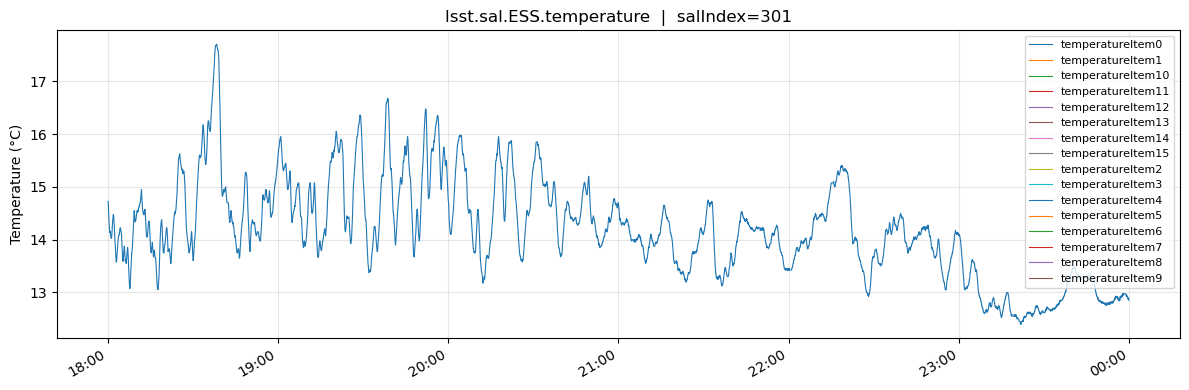

In [7]:
temp_cols = [c for c in df_temp.columns if "temperature" in c.lower()]

fig, ax = plt.subplots(figsize=(12, 4))
for col in temp_cols:
    ax.plot(df_temp.index, df_temp[col], lw=0.8, label=col)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_ylabel("Temperature (°C)")
ax.set_title(f"{temp_topic}  |  salIndex={sal_index}")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Humidity Sensors

Relevant indices: 111 (camera inlet), 112 (M2), 113 (M1M3), 201 (AuxTel)

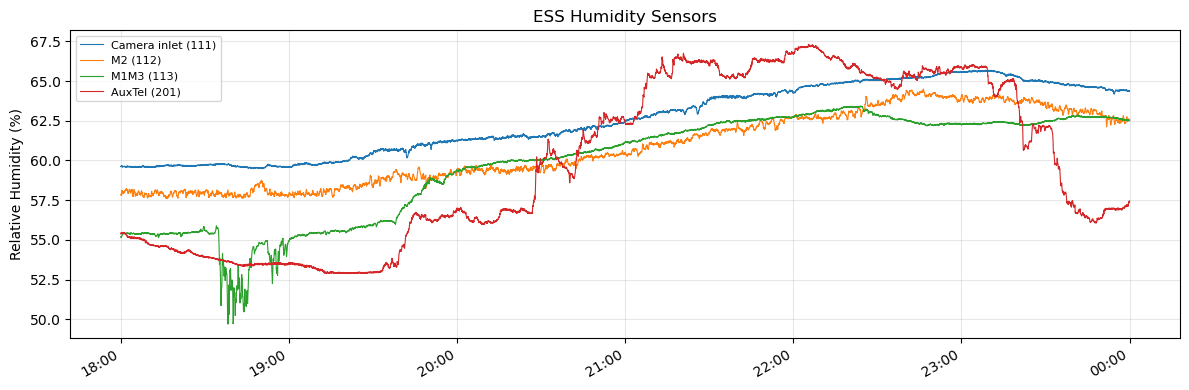

In [17]:
humidity_topic = "lsst.sal.ESS.relativeHumidity"

indices = {111: "Camera inlet", 112: "M2", 113: "M1M3", 201: "AuxTel"}

fig, ax = plt.subplots(figsize=(12, 4))
for idx, label in indices.items():
    df_h = await client.select_time_series(
        humidity_topic, fields="relativeHumidityItem", start=t_start, end=t_end, index=idx
    )
    if not df_h.empty:
        ax.plot(df_h.index, df_h["relativeHumidityItem"], lw=0.8, label=f"{label} ({idx})")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_ylabel("Relative Humidity (%)")
ax.set_title("ESS Humidity Sensors")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Wind / Anemometers

2D wind (Windsonic): 204 (AuxTel dome), 441 (louver H1), 443 (louver H2)  
Air turbulence (Gill 3D): 110 (TMA platform), 123–126 (TMA top ring)  
Weather station: 301

In [18]:
wind_topic = "lsst.sal.ESS.airFlow"
sal_index  = 301  # weather station — change as needed

df_wind = await client.select_time_series(
    wind_topic, fields="*", start=t_start, end=t_end, index=sal_index
)
print(f"Rows: {len(df_wind)}   Columns: {list(df_wind.columns)}")
df_wind.head()

Rows: 16875   Columns: ['direction', 'directionStdDev', 'location', 'maxSpeed', 'private_efdStamp', 'private_identity', 'private_kafkaStamp', 'private_origin', 'private_rcvStamp', 'private_revCode', 'private_seqNum', 'private_sndStamp', 'salIndex', 'sensorName', 'speed', 'speedStdDev', 'timestamp']


,direction,directionStdDev,location,maxSpeed,private_efdStamp,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,salIndex,sensorName,speed,speedStdDev,timestamp
2026-01-14 18:00:00.855720+00:00,7.790008,0.582152,Weather tower,5.5878,1.768414e+09,ESS:301,1.768414e+09,13,0,c9def8cc,1957516,1.768414e+09,301,Weather tower airflow,5.5878,0.000000,1.768414e+09
2026-01-14 18:00:02.135088+00:00,9.594966,1.079588,Weather tower,5.5878,1.768414e+09,ESS:301,1.768414e+09,13,0,c9def8cc,1957517,1.768414e+09,301,Weather tower airflow,5.2542,0.000000,1.768414e+09
2026-01-14 18:00:03.415104+00:00,11.309999,0.742235,Weather tower,5.2542,1.768414e+09,ESS:301,1.768414e+09,13,0,c9def8cc,1957518,1.768414e+09,301,Weather tower airflow,5.0874,0.123599,1.768414e+09
2026-01-14 18:00:04.695034+00:00,11.025001,0.440314,Weather tower,5.2542,1.768414e+09,ESS:301,1.768414e+09,13,0,c9def8cc,1957519,1.768414e+09,301,Weather tower airflow,5.2542,0.000000,1.768414e+09
2026-01-14 18:00:05.974940+00:00,10.839999,0.832118,Weather tower,5.2542,1.768414e+09,ESS:301,1.768414e+09,13,0,c9def8cc,1957520,1.768414e+09,301,Weather tower airflow,5.0874,0.030900,1.768414e+09


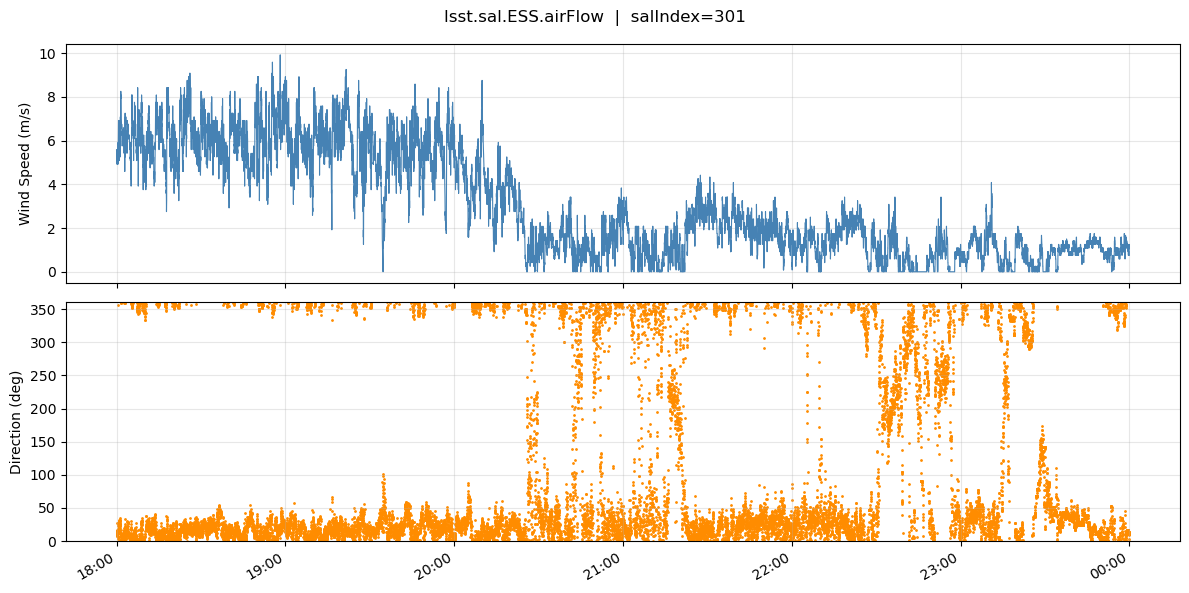

In [19]:
fig, (ax_speed, ax_dir) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

speed_col = "speed"
dir_col   = "direction"

if speed_col in df_wind.columns:
    ax_speed.plot(df_wind.index, df_wind[speed_col], lw=0.8, color="steelblue")
if dir_col in df_wind.columns:
    ax_dir.scatter(df_wind.index, df_wind[dir_col], s=1, color="darkorange")

ax_speed.set_ylabel("Wind Speed (m/s)")
ax_dir.set_ylabel("Direction (deg)")
ax_dir.set_ylim(0, 360)
ax_dir.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.suptitle(f"{wind_topic}  |  salIndex={sal_index}")
for ax in (ax_speed, ax_dir):
    ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Accelerometers (Packed Time Series)

Accelerometer topics store packed vector samples at up to 100 Hz.
Use `select_packed_time_series` to unpack them.

Indices: 104 (TMA — SST ring, spider spindle, M2 surrogate), 202 (AuxTel — M1, M2, truss)

In [23]:
accel_topic = "lsst.sal.ESS.accelerometer"
sal_index   = 104  # AuxTel accelerometers; use 104 for TMA

df_accel = await client.select_packed_time_series(
    accel_topic,
    base_fields="accelerationX",  # also try accelerationY, accelerationZ
    start=t_start,
    end=t_end,
    index=sal_index,
)
print(f"Rows: {len(df_accel)}   Columns: {list(df_accel.columns)}")
df_accel.head()

TypeError: unsupported operand type(s) for -: 'NoneType' and 'NoneType'

In [24]:
accel_cols = df_accel.select_dtypes(include="number").columns.tolist()

fig, ax = plt.subplots(figsize=(12, 4))
for col in accel_cols:
    ax.plot(df_accel.index, df_accel[col], lw=0.5, label=col, alpha=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_ylabel("Acceleration (m/s²)")
ax.set_title(f"{accel_topic}  |  salIndex={sal_index}")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

NameError: name 'df_accel' is not defined

In [25]:
# Power Spectral Density of one accelerometer channel
col = accel_cols[0] if accel_cols else None

if col and len(df_accel) > 1:
    dt = (df_accel.index[1] - df_accel.index[0]).total_seconds()
    fs = 1.0 / dt
    signal = df_accel[col].dropna().values
    freqs = np.fft.rfftfreq(len(signal), d=dt)
    psd   = (np.abs(np.fft.rfft(signal)) ** 2) / (fs * len(signal))

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.semilogy(freqs, psd)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("PSD ((m/s²)²/Hz)")
    ax.set_title(f"PSD — {col}  |  salIndex={sal_index}")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No data or only one sample — cannot compute PSD.")

NameError: name 'accel_cols' is not defined

## Weather Station Overview (salIndex 301)

The calibration hill Young 32400 station reports wind, humidity, pressure, temperature, and rain.

In [30]:
weather_index = 301
weather_topics = {
    "airFlow"          : "lsst.sal.ESS.airFlow",
    "relativeHumidity" : "lsst.sal.ESS.relativeHumidity",
    "atmosphericPressure": "lsst.sal.ESS.pressure",
    "airTemperature"   : "lsst.sal.ESS.temperature",
}

weather_data = {}
for label, wtopic in weather_topics.items():
    df_w = await client.select_time_series(
        wtopic, fields="*", start=t_start, end=t_end, index=weather_index
    )
    weather_data[label] = df_w
    print(f"{label:30s}  rows={len(df_w)}")

airFlow                         rows=16875
relativeHumidity                rows=5625
atmosphericPressure             rows=5625
airTemperature                  rows=5625


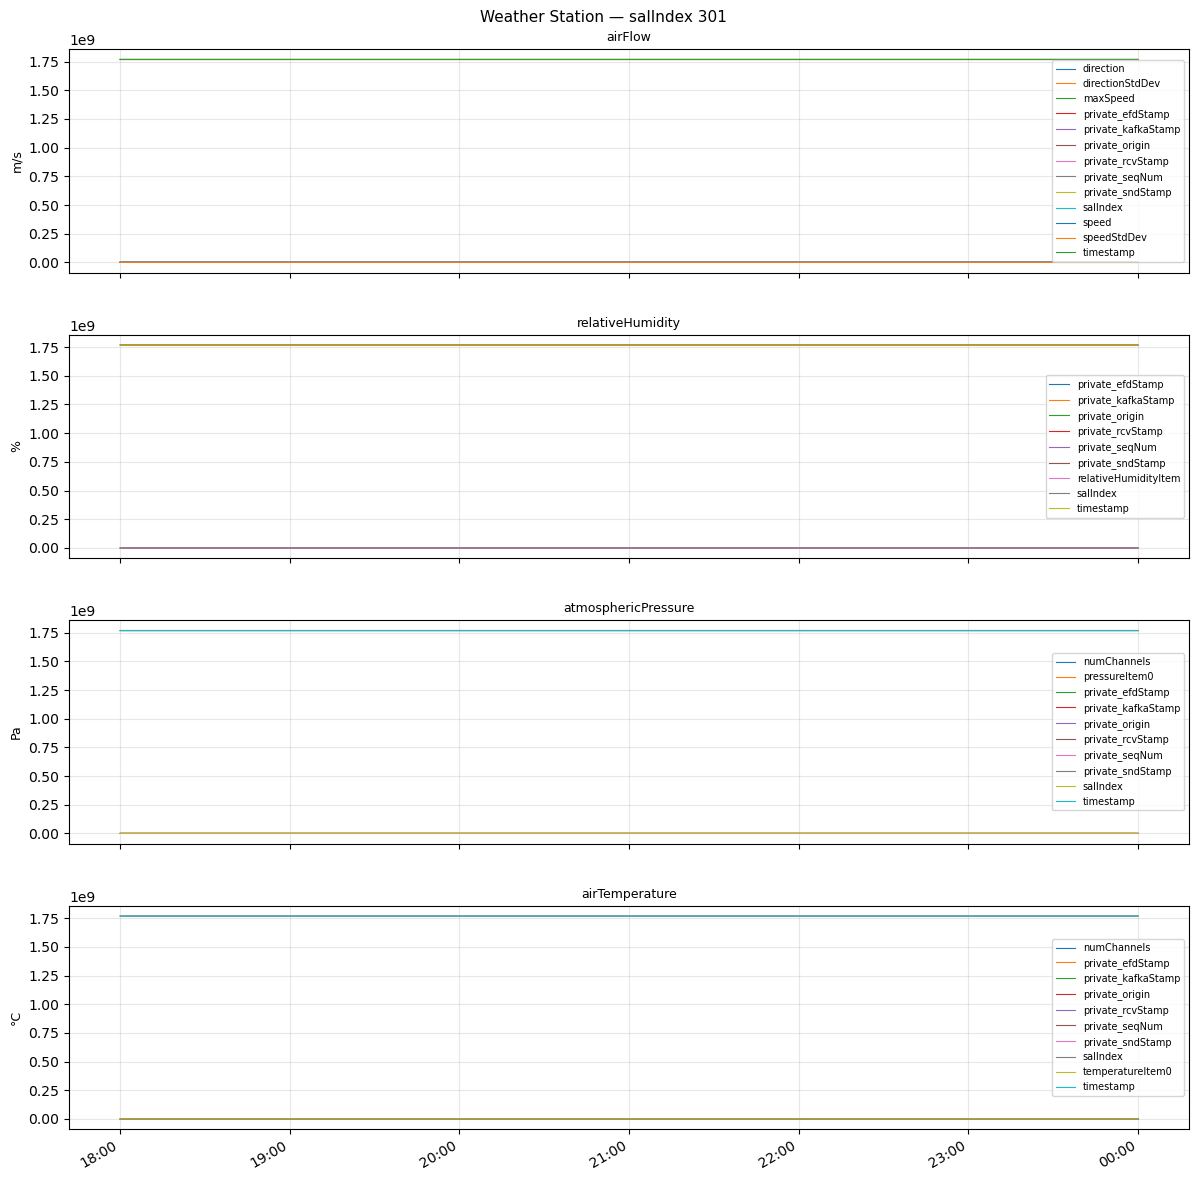

In [31]:
fig, axes = plt.subplots(len(weather_data), 1,
                         figsize=(12, 3 * len(weather_data)),
                         sharex=True)
units = {
    "airFlow": "m/s",
    "relativeHumidity": "%",
    "atmosphericPressure": "Pa",
    "airTemperature": "°C",
}
for ax, (label, df_w) in zip(axes, weather_data.items()):
    num_cols = df_w.select_dtypes(include="number").columns
    for col in num_cols:
        ax.plot(df_w.index, df_w[col], lw=0.8, label=col)
    ax.set_ylabel(units.get(label, ""), fontsize=9)
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.suptitle(f"Weather Station — salIndex {weather_index}", fontsize=11)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Generic Query — Any ESS Topic + salIndex

In [ ]:
# Edit these two variables to query any sensor
query_topic = ess_topics[0]
query_index = 301

df_generic = await client.select_time_series(
    query_topic, fields="*", start=t_start, end=t_end, index=query_index
)
print(f"Topic : {query_topic}")
print(f"Index : {query_index}")
print(f"Rows  : {len(df_generic)}")
df_generic.head()

In [ ]:
numeric_cols = df_generic.select_dtypes(include="number").columns.tolist()
if not numeric_cols:
    print("No numeric columns to plot.")
else:
    fig, axes = plt.subplots(len(numeric_cols), 1,
                             figsize=(12, 3 * len(numeric_cols)),
                             sharex=True)
    if len(numeric_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, numeric_cols):
        ax.plot(df_generic.index, df_generic[col], lw=0.8)
        ax.set_ylabel(col, fontsize=9)
        ax.grid(True, alpha=0.3)
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    fig.suptitle(f"{query_topic}  |  salIndex={query_index}", fontsize=10)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()